# Network Attack Detection Machine Learning

## 1. Title and Introduction

This notebook performs machine learning classification on packet-level network traffic for the `attack-lab` project.

The dataset was prepared from Wireshark PCAP captures and was previously analyzed using exploratory data analysis (EDA). The goal here is to train and compare supervised machine learning models that classify traffic into three classes:

- `Normal`
- `Ping_Flood`
- `SYN_Flood`

The models compared in this lab are Random Forest, Decision Tree, and Logistic Regression.

## 2. Import Libraries

Import the data analysis, visualization, preprocessing, model training, and evaluation libraries.

In [1]:
# File path helper
from pathlib import Path

# Data analysis libraries
import numpy as np
import pandas as pd
import joblib

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine learning models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Use a clean plotting style for presentation-ready figures
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## 3. Load Dataset

Read the cleaned dataset from `csv/final_dataset_clean.csv`, then display the first few rows, shape, and column names.

In [2]:
# Locate the dataset whether the notebook is run from project root or notebooks/
dataset_path = Path("csv/final_dataset_clean.csv")
if not dataset_path.exists():
    dataset_path = Path("../csv/final_dataset_clean.csv")

# Read the cleaned CSV dataset
df = pd.read_csv(dataset_path)

# Standard numeric-to-name mapping used throughout the notebook
label_map = {
    0: "Normal",
    1: "Ping_Flood",
    2: "SYN_Flood",
}

# Display basic dataset information
print("Loaded dataset from:", dataset_path)
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

# Display the first few rows
df.head()

Loaded dataset from: ../csv/final_dataset_clean.csv
Dataset shape: (23685, 17)

Column names:
['frame.time_epoch', 'ip.src', 'ip.dst', 'ip.proto', 'frame.len', 'tcp.srcport', 'tcp.dstport', 'tcp.flags.syn', 'tcp.flags.ack', 'tcp.flags.reset', 'ip.ttl', 'icmp.type', 'icmp.code', 'label', 'label_name', 'source_file', 'inter_arrival']


,frame.time_epoch,ip.src,ip.dst,ip.proto,frame.len,tcp.srcport,tcp.dstport,tcp.flags.syn,tcp.flags.ack,tcp.flags.reset,ip.ttl,icmp.type,icmp.code,label,label_name,source_file,inter_arrival
0,1.776764e+09,10.10.166.245,10.10.166.129,1.0,98,0.0,0.0,0.0,0.0,0.0,64.0,8.0,0.0,0,Normal,normal.csv,0.000000
1,1.776764e+09,10.10.166.129,10.10.166.245,1.0,98,0.0,0.0,0.0,0.0,0.0,128.0,0.0,0.0,0,Normal,normal.csv,0.000309
2,1.776764e+09,10.10.166.245,10.10.166.129,1.0,98,0.0,0.0,0.0,0.0,0.0,64.0,8.0,0.0,0,Normal,normal.csv,1.023629
3,1.776764e+09,10.10.166.129,10.10.166.245,1.0,98,0.0,0.0,0.0,0.0,0.0,128.0,0.0,0.0,0,Normal,normal.csv,0.000983
4,1.776764e+09,0,0,0.0,60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Normal,normal.csv,0.644947


## 4. Data Preparation

Use `label` as the target column if it exists. If `label` is not present, use `label_num` instead. Metadata and non-numeric columns are removed before training so that only numeric machine learning features remain.

In [3]:
# Select the target column using the required priority
if "label" in df.columns:
    target_column = "label"
elif "label_num" in df.columns:
    target_column = "label_num"
else:
    raise ValueError("Expected either 'label' or 'label_num' as the target column.")

# Convert known text labels to numeric labels if needed
label_name_to_num = {
    "Normal": 0,
    "Ping": 1,
    "Ping_Flood": 1,
    "SYN": 2,
    "SYN_Flood": 2,
}
y = df[target_column].replace(label_name_to_num).astype(int)

# Create display labels for reports and plots
label_order = sorted(y.unique())
target_names = [label_map.get(int(label), str(label)) for label in label_order]
y_display = y.map(label_map).fillna(y.astype(str))

# Remove metadata, identifiers, raw labels, and columns that should not be model features
metadata_columns = [
    "ip.src",
    "ip.dst",
    "label_name",
    "label_display",
    "source_file",
    "frame.time_epoch",  # raw capture time can leak capture/session identity
]
label_columns = ["label", "label_num"]
columns_to_remove = metadata_columns + label_columns

# Keep only numeric model features after removing metadata and labels
feature_candidates = df.drop(columns=columns_to_remove, errors="ignore")
X = feature_candidates.select_dtypes(include=[np.number]).copy()

# Confirm the final feature set
print("Target column used:", target_column)
print("\nClass distribution:")
print(y_display.value_counts().reindex(target_names, fill_value=0))
print("\nFinal feature columns used for training:")
print(X.columns.tolist())
print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

# Preview the numeric feature matrix
X.head()

Target column used: label

Class distribution:
label
Normal         2516
Ping_Flood    10144
SYN_Flood     11025
Name: count, dtype: int64

Final feature columns used for training:
['ip.proto', 'frame.len', 'tcp.srcport', 'tcp.dstport', 'tcp.flags.syn', 'tcp.flags.ack', 'tcp.flags.reset', 'ip.ttl', 'icmp.type', 'icmp.code', 'inter_arrival']

Feature matrix shape: (23685, 11)
Target vector shape: (23685,)


,ip.proto,frame.len,tcp.srcport,tcp.dstport,tcp.flags.syn,tcp.flags.ack,tcp.flags.reset,ip.ttl,icmp.type,icmp.code,inter_arrival
0,1.0,98,0.0,0.0,0.0,0.0,0.0,64.0,8.0,0.0,0.000000
1,1.0,98,0.0,0.0,0.0,0.0,0.0,128.0,0.0,0.0,0.000309
2,1.0,98,0.0,0.0,0.0,0.0,0.0,64.0,8.0,0.0,1.023629
3,1.0,98,0.0,0.0,0.0,0.0,0.0,128.0,0.0,0.0,0.000983
4,0.0,60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.644947


## 5. Train-Test Split

Split the prepared data into training and testing sets using an 80/20 split. Stratification keeps the class distribution similar in both sets.

In [4]:
# Split the dataset into train and test partitions
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# Print split sizes and class balance
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.map(label_map).value_counts().reindex(target_names, fill_value=0))

print("\nTesting class distribution:")
print(y_test.map(label_map).value_counts().reindex(target_names, fill_value=0))

X_train shape: (18948, 11)
X_test shape: (4737, 11)
y_train shape: (18948,)
y_test shape: (4737,)

Training class distribution:
label
Normal        2013
Ping_Flood    8115
SYN_Flood     8820
Name: count, dtype: int64

Testing class distribution:
label
Normal         503
Ping_Flood    2029
SYN_Flood     2205
Name: count, dtype: int64


## 6. Feature Scaling

Apply `StandardScaler` only for Logistic Regression. Tree-based models such as Random Forest and Decision Tree do not require feature scaling.

In [5]:
# Fit the scaler only on training data to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("Scaling completed for Logistic Regression only.")
X_train_scaled.head()

Scaling completed for Logistic Regression only.


,ip.proto,frame.len,tcp.srcport,tcp.dstport,tcp.flags.syn,tcp.flags.ack,tcp.flags.reset,ip.ttl,icmp.type,icmp.code,inter_arrival
18361,1.072403,-1.169561,-0.535965,1.109181,-0.551417,1.819957,1.822928,0.998721,-0.6019,0.0,-0.031857
10893,-0.930306,0.713082,-0.539901,-0.537274,-0.551417,-0.549463,-0.548568,0.998721,-0.6019,0.0,-0.031438
22924,1.072403,-0.475956,1.454574,-0.533322,1.813510,-0.549463,-0.548568,-0.982203,-0.6019,0.0,-0.026552
12447,-0.930306,0.713082,-0.539901,-0.537274,-0.551417,-0.549463,-0.548568,0.998721,-0.6019,0.0,-0.031464
15390,1.072403,-0.475956,1.262389,-0.533322,1.813510,-0.549463,-0.548568,-0.982203,-0.6019,0.0,-0.026227


## 7. Train Machine Learning Models

Train three classifiers using reasonable default settings:

- Random Forest Classifier
- Decision Tree Classifier
- Logistic Regression

In [6]:
# Initialize the required models
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
    ),
}

# Train tree-based models on unscaled features
models["Random Forest"].fit(X_train, y_train)
models["Decision Tree"].fit(X_train, y_train)

# Train Logistic Regression on scaled features
models["Logistic Regression"].fit(X_train_scaled, y_train)

print("All models have been trained successfully.")

All models have been trained successfully.


## 8. Model Evaluation

Evaluate each model using accuracy, classification report, and confusion matrix.

In [7]:
# Evaluate every model and store predictions/metrics for later visualization
evaluation_results = {}

for model_name, model in models.items():
    # Use scaled test features only for Logistic Regression
    if model_name == "Logistic Regression":
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    # Calculate standard classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    report_text = classification_report(
        y_test,
        y_pred,
        labels=label_order,
        target_names=target_names,
        zero_division=0,
    )
    report_dict = classification_report(
        y_test,
        y_pred,
        labels=label_order,
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
    cm = confusion_matrix(y_test, y_pred, labels=label_order)

    # Save results for later sections
    evaluation_results[model_name] = {
        "predictions": y_pred,
        "accuracy": accuracy,
        "classification_report": report_dict,
        "confusion_matrix": cm,
    }

    # Print evaluation output
    print("=" * 70)
    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(report_text)
    print("Confusion Matrix:")
    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual {name}" for name in target_names],
        columns=[f"Predicted {name}" for name in target_names],
    )
    print(cm_df)
    print()

Model: Random Forest
Accuracy: 0.9208

Classification Report:
              precision    recall  f1-score   support

      Normal       0.62      0.66      0.64       503
  Ping_Flood       0.91      0.90      0.91      2029
   SYN_Flood       1.00      1.00      1.00      2205

    accuracy                           0.92      4737
   macro avg       0.85      0.85      0.85      4737
weighted avg       0.92      0.92      0.92      4737

Confusion Matrix:
                   Predicted Normal  Predicted Ping_Flood  Predicted SYN_Flood
Actual Normal                   330                   170                    3
Actual Ping_Flood               198                  1830                    1
Actual SYN_Flood                  2                     1                 2202

Model: Decision Tree
Accuracy: 0.9086

Classification Report:
              precision    recall  f1-score   support

      Normal       0.56      0.68      0.61       503
  Ping_Flood       0.92      0.87      0.89      20

## 9. Visualization

Plot confusion matrices for each model and create a comparison bar chart of model accuracies.

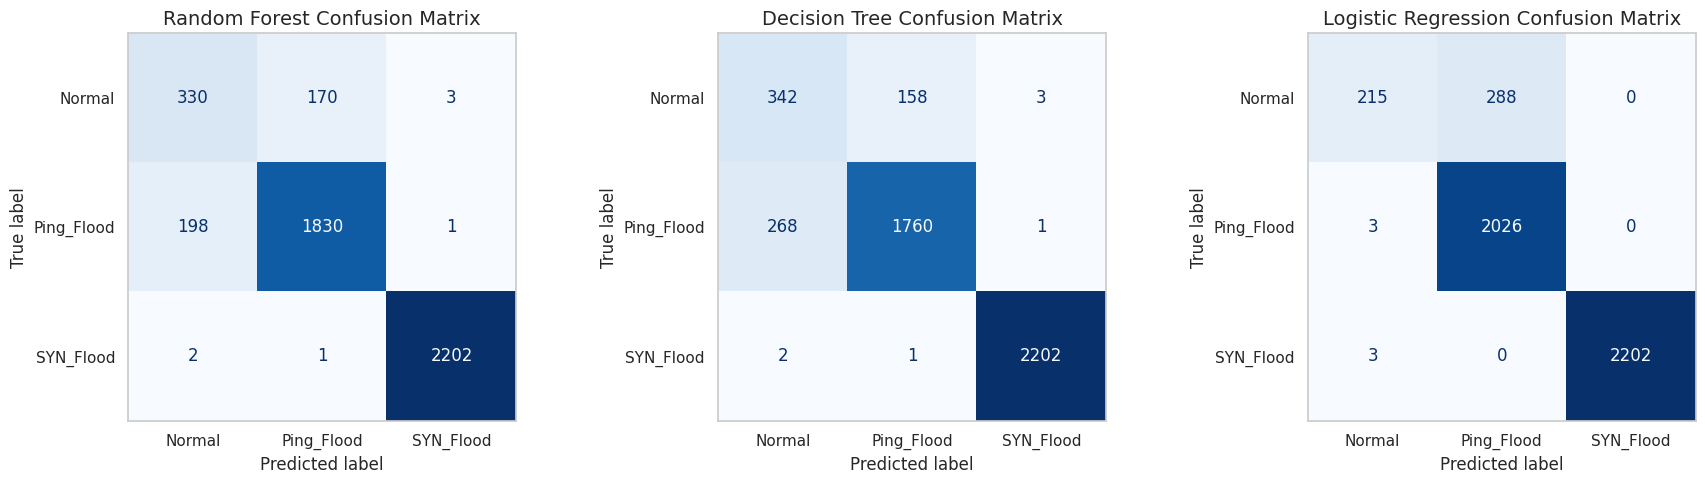

In [8]:
# Plot confusion matrices side by side for all models
fig, axes = plt.subplots(1, len(models), figsize=(18, 5))

for ax, (model_name, result) in zip(axes, evaluation_results.items()):
    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=result["confusion_matrix"],
        display_labels=target_names,
    )
    cm_display.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"{model_name} Confusion Matrix")
    ax.grid(False)

plt.tight_layout()
plt.show()

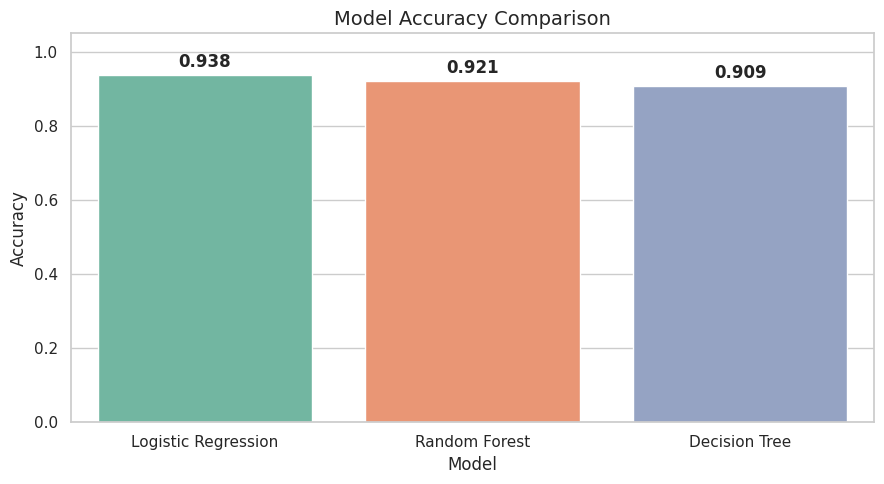

,Model,Accuracy
2,Logistic Regression,0.937935
0,Random Forest,0.920836
1,Decision Tree,0.908592


In [9]:
# Create a model accuracy comparison table
accuracy_df = pd.DataFrame(
    {
        "Model": list(evaluation_results.keys()),
        "Accuracy": [result["accuracy"] for result in evaluation_results.values()],
    }
).sort_values("Accuracy", ascending=False)

# Plot model accuracies
plt.figure(figsize=(9, 5))
sns.barplot(
    data=accuracy_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="Set2",
    legend=False,
)
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)

# Add accuracy labels above bars
for index, row in accuracy_df.reset_index(drop=True).iterrows():
    plt.text(
        index,
        row["Accuracy"] + 0.01,
        f"{row['Accuracy']:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

accuracy_df

## 10. Decision Tree Analysis

Following the Decision Tree reference notebook, inspect feature importance and visualize the learned tree structure. The plotted tree is limited to the top levels so it stays readable in the lab notebook.

Decision Tree feature importances:


,Feature,Importance
2,tcp.srcport,0.539938
10,inter_arrival,0.459171
0,ip.proto,0.000719
1,frame.len,0.000172
3,tcp.dstport,0.000000
5,tcp.flags.ack,0.000000
4,tcp.flags.syn,0.000000
6,tcp.flags.reset,0.000000
7,ip.ttl,0.000000
8,icmp.type,0.000000


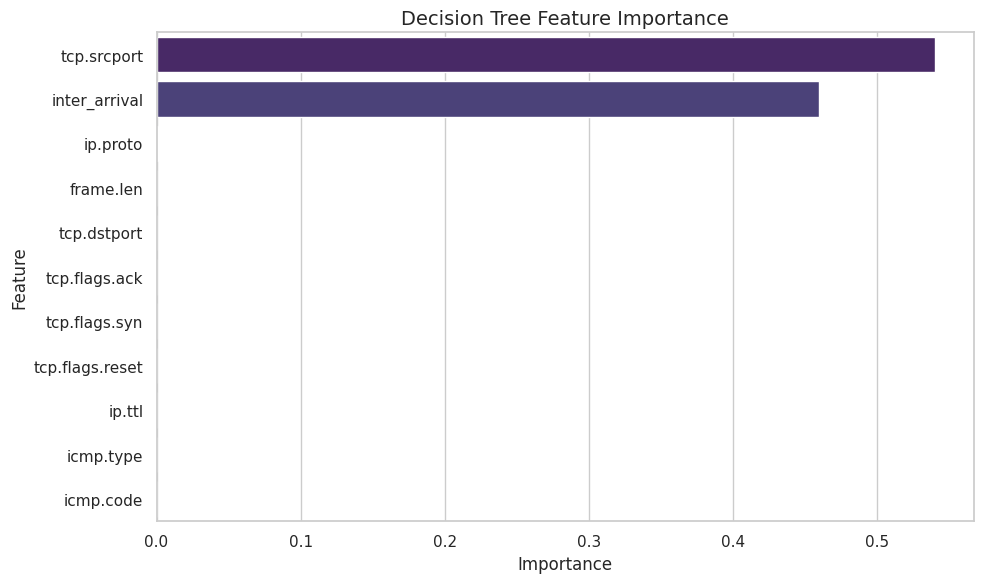

In [10]:
# Extract Decision Tree feature importances
decision_tree_model = models["Decision Tree"]

decision_tree_importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": decision_tree_model.feature_importances_,
    }
).sort_values("Importance", ascending=False)

print("Decision Tree feature importances:")
display(decision_tree_importance)

# Visualize feature importance as a horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=decision_tree_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False,
)
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

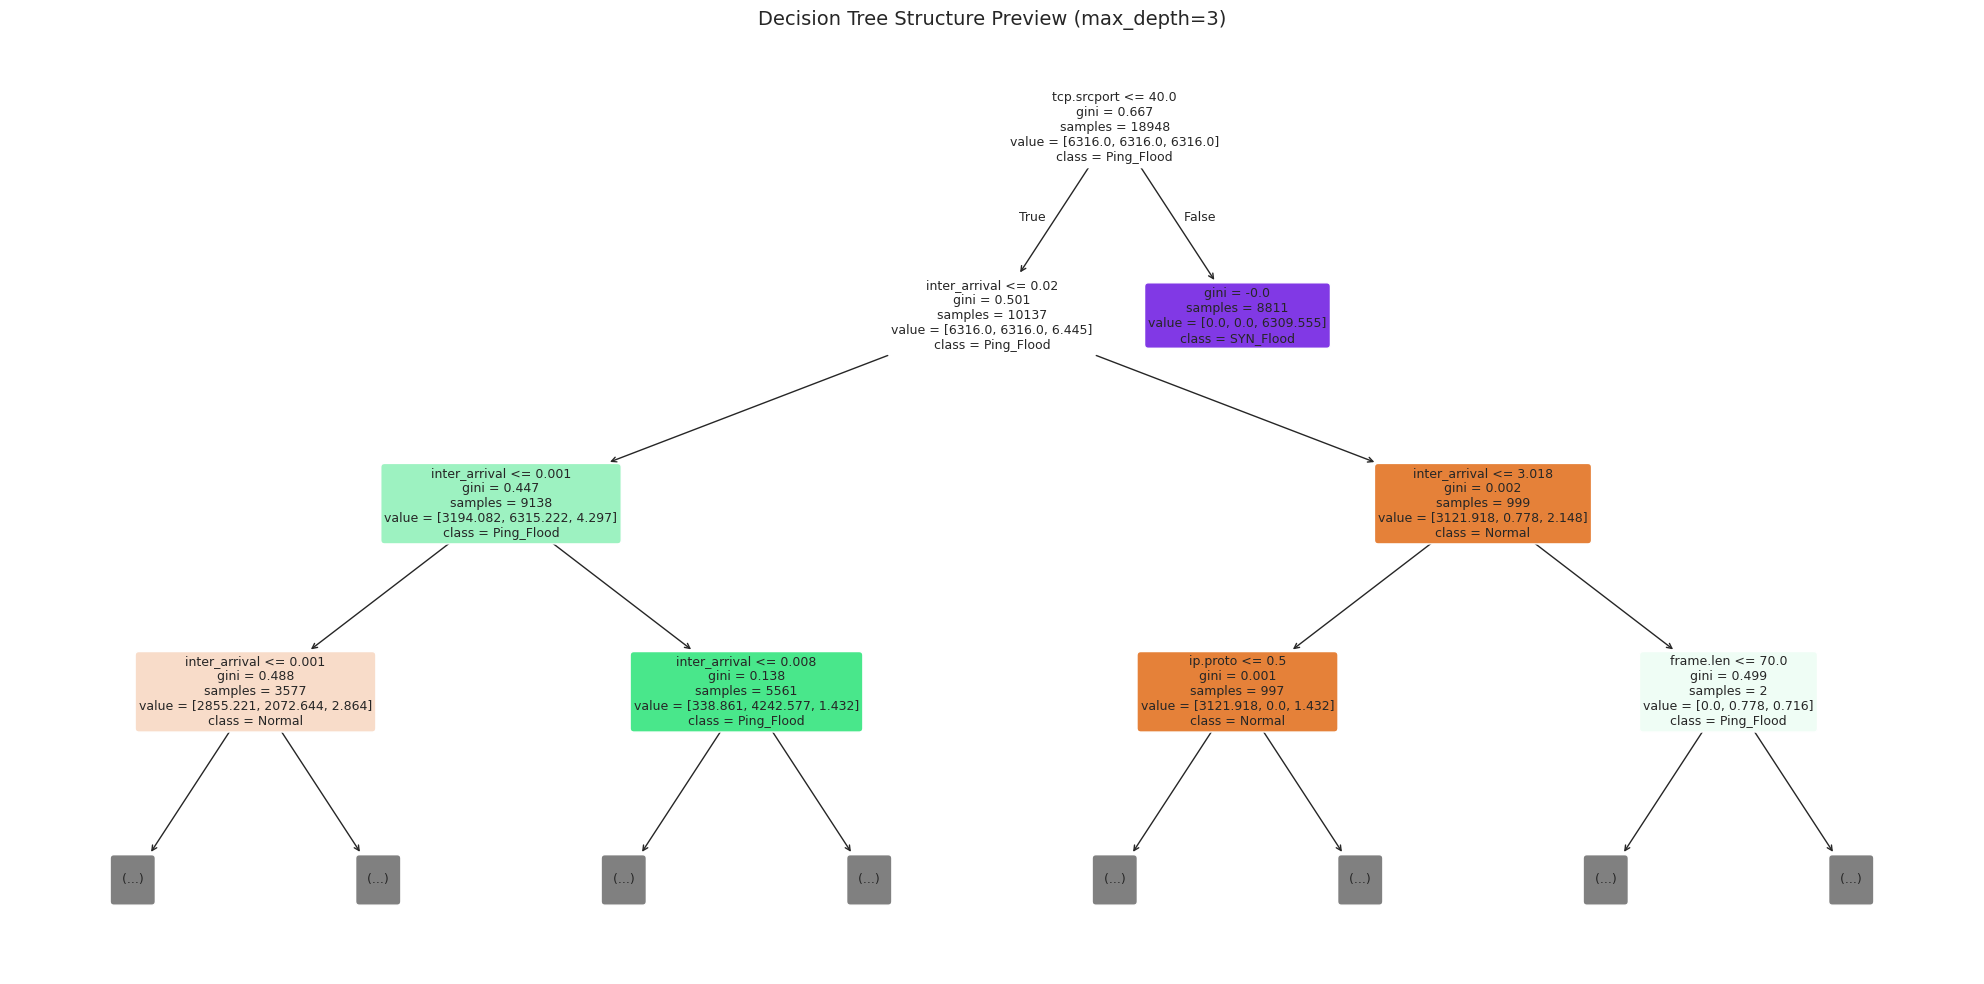

In [11]:
# Plot a readable preview of the trained Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(
    decision_tree_model,
    feature_names=X.columns.tolist(),
    class_names=target_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
)
plt.title("Decision Tree Structure Preview (max_depth=3)")
plt.tight_layout()
plt.show()

## 11. Logistic Regression Analysis

Following the Logistic Regression reference notebook, inspect model coefficients and view both regular and normalized confusion matrices. Logistic Regression uses the scaled feature matrix.

Logistic Regression coefficients by class:


,ip.proto,frame.len,tcp.srcport,tcp.dstport,tcp.flags.syn,tcp.flags.ack,tcp.flags.reset,ip.ttl,icmp.type,icmp.code,inter_arrival
Normal,-1.177269,0.006558,-0.691530,-0.538304,-0.772934,-0.594032,-0.545524,0.305574,0.159991,0.0,4.075333
Ping_Flood,-0.888288,0.019881,-0.498322,-0.597455,-0.539941,-0.694991,-0.590533,0.961370,1.188130,0.0,-8.087330
SYN_Flood,2.065557,-0.026439,1.189851,1.135759,1.312876,1.289023,1.136058,-1.266944,-1.348121,0.0,4.011997


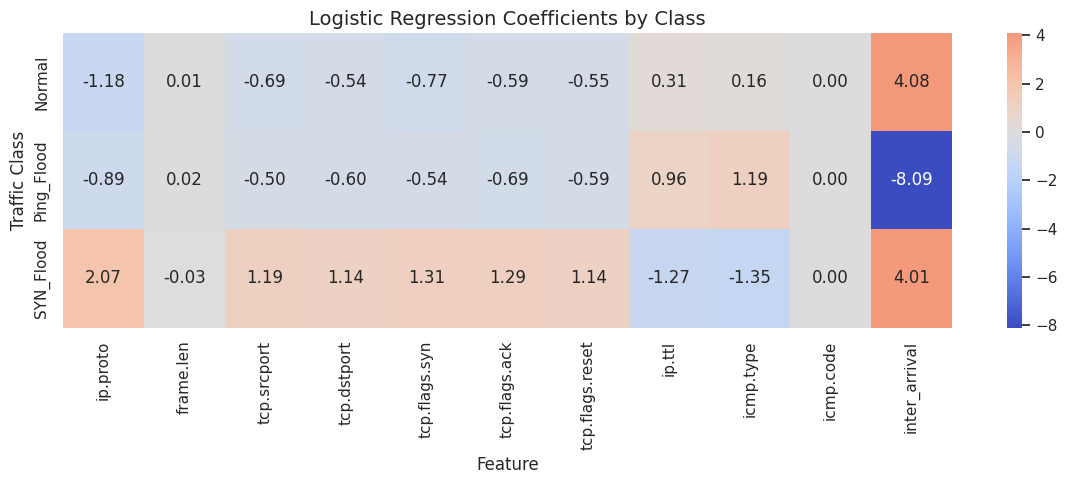

In [12]:
# Extract Logistic Regression coefficients for each traffic class
logistic_model = models["Logistic Regression"]

logistic_coefficients = pd.DataFrame(
    logistic_model.coef_,
    index=target_names,
    columns=X.columns,
)

print("Logistic Regression coefficients by class:")
display(logistic_coefficients)

# Visualize coefficients with a heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(
    logistic_coefficients,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)
plt.title("Logistic Regression Coefficients by Class")
plt.xlabel("Feature")
plt.ylabel("Traffic Class")
plt.tight_layout()
plt.show()

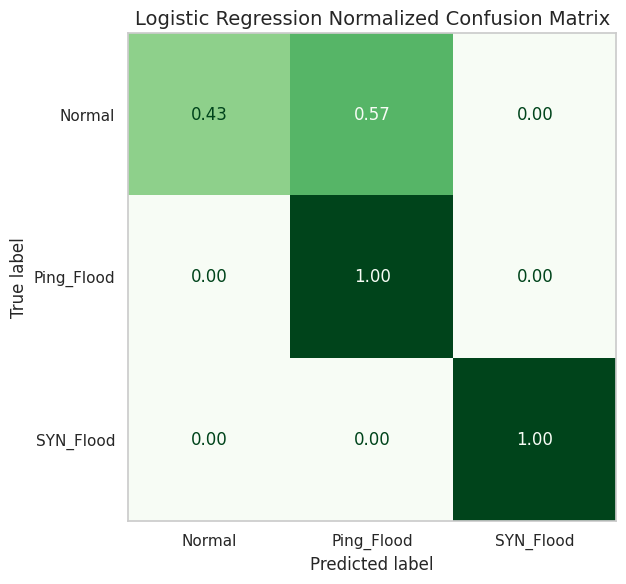

In [13]:
# Plot a normalized confusion matrix for Logistic Regression
logistic_predictions = evaluation_results["Logistic Regression"]["predictions"]
logistic_cm_normalized = confusion_matrix(
    y_test,
    logistic_predictions,
    labels=label_order,
    normalize="true",
)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm_normalized,
    display_labels=target_names,
).plot(ax=ax, cmap="Greens", values_format=".2f", colorbar=False)
ax.set_title("Logistic Regression Normalized Confusion Matrix")
ax.grid(False)
plt.tight_layout()
plt.show()

## 12. Random Forest Analysis

Following the Random Forest reference notebook, inspect feature importance and compare test error across different numbers of trees.

Random Forest feature importances:


,Feature,Importance
10,inter_arrival,0.446599
3,tcp.dstport,0.151391
2,tcp.srcport,0.148013
0,ip.proto,0.121157
1,frame.len,0.048602
6,tcp.flags.reset,0.019755
5,tcp.flags.ack,0.018907
4,tcp.flags.syn,0.017046
8,icmp.type,0.015565
7,ip.ttl,0.012965


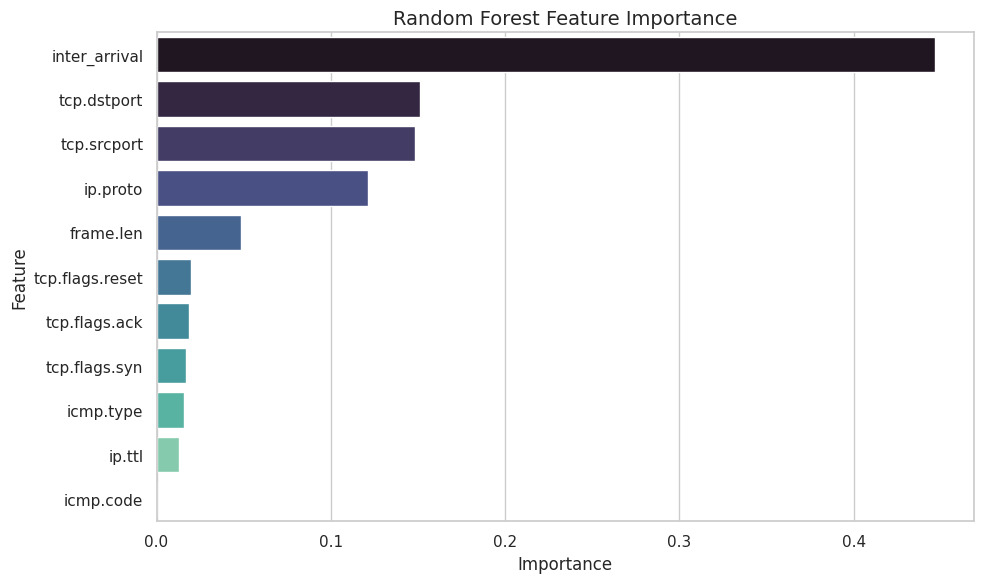

In [14]:
# Extract Random Forest feature importances
random_forest_model = models["Random Forest"]

random_forest_importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": random_forest_model.feature_importances_,
    }
).sort_values("Importance", ascending=False)

print("Random Forest feature importances:")
display(random_forest_importance)

# Visualize feature importance as a horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=random_forest_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="mako",
    legend=False,
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

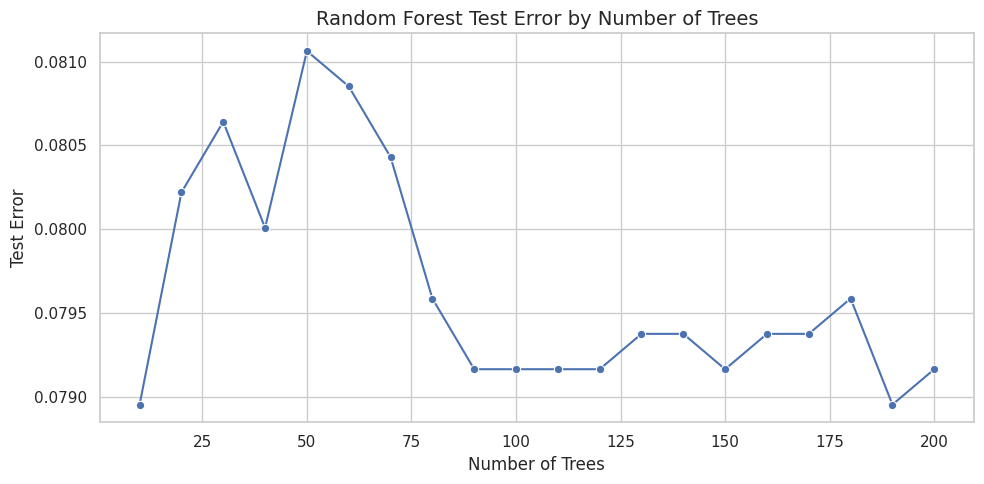

,n_estimators,Test Error,Test Accuracy
0,10,0.078953,0.921047
1,20,0.080220,0.919780
2,30,0.080642,0.919358
3,40,0.080008,0.919992
4,50,0.081064,0.918936
5,60,0.080853,0.919147
6,70,0.080431,0.919569
7,80,0.079586,0.920414
8,90,0.079164,0.920836
9,100,0.079164,0.920836


In [15]:
# Compare Random Forest test error for different numbers of trees
n_estimators_range = range(10, 210, 10)
rf_test_errors = []
rf_test_accuracies = []

for n_estimators in n_estimators_range:
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    )
    rf_model.fit(X_train, y_train)
    rf_predictions = rf_model.predict(X_test)
    rf_accuracy = accuracy_score(y_test, rf_predictions)
    rf_test_accuracies.append(rf_accuracy)
    rf_test_errors.append(1 - rf_accuracy)

rf_error_df = pd.DataFrame(
    {
        "n_estimators": list(n_estimators_range),
        "Test Error": rf_test_errors,
        "Test Accuracy": rf_test_accuracies,
    }
)

# Plot the Random Forest test error curve
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=rf_error_df,
    x="n_estimators",
    y="Test Error",
    marker="o",
)
plt.title("Random Forest Test Error by Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Test Error")
plt.tight_layout()
plt.show()

rf_error_df

## 13. Best Model Selection

Identify the best-performing model using accuracy and the classification report. Macro F1-score is included to check whether a model performs well across all classes, not only the majority class.

In [16]:
# Build a compact comparison table using accuracy and classification report averages
model_summary = []
for model_name, result in evaluation_results.items():
    report = result["classification_report"]
    model_summary.append(
        {
            "Model": model_name,
            "Accuracy": result["accuracy"],
            "Macro Precision": report["macro avg"]["precision"],
            "Macro Recall": report["macro avg"]["recall"],
            "Macro F1": report["macro avg"]["f1-score"],
            "Weighted F1": report["weighted avg"]["f1-score"],
        }
    )

summary_df = pd.DataFrame(model_summary).sort_values(
    by=["Accuracy", "Macro F1", "Weighted F1"],
    ascending=False,
)

best_model_name = summary_df.iloc[0]["Model"]
best_accuracy = summary_df.iloc[0]["Accuracy"]
best_macro_f1 = summary_df.iloc[0]["Macro F1"]

print("Model comparison summary:")
display(summary_df)

print(f"Best-performing model: {best_model_name}")
print(f"Best accuracy: {best_accuracy:.4f}")
print(f"Best macro F1-score: {best_macro_f1:.4f}")

if best_model_name == "Random Forest":
    print(
        "\nInterpretation: Random Forest performed best because it combines many "
        "decision trees, captures non-linear relationships between packet features, "
        "and is robust for tabular network traffic data."
    )
else:
    print(
        f"\nInterpretation: {best_model_name} achieved the highest accuracy in this run. "
        "Compare its macro precision, macro recall, and macro F1-score to confirm "
        "that the model performs well across Normal, Ping_Flood, and SYN_Flood classes. "
        "Random Forest is still generally expected to be a strong model for this type "
        "of tabular network traffic dataset."
    )

Model comparison summary:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
2,Logistic Regression,0.937935,0.949464,0.808199,0.842079,0.927864
0,Random Forest,0.920836,0.845124,0.852208,0.848506,0.921594
1,Decision Tree,0.908592,0.824718,0.848661,0.834486,0.911781


Best-performing model: Logistic Regression
Best accuracy: 0.9379
Best macro F1-score: 0.8421

Interpretation: Logistic Regression achieved the highest accuracy in this run. Compare its macro precision, macro recall, and macro F1-score to confirm that the model performs well across Normal, Ping_Flood, and SYN_Flood classes. Random Forest is still generally expected to be a strong model for this type of tabular network traffic dataset.


## 14. Save Models as Joblib Files

Save each trained model as a separate `.joblib` file. The Logistic Regression artifact also includes the fitted `StandardScaler`, because that model was trained on scaled features.

In [17]:
# Create a models directory whether the notebook is run from project root or notebooks/
project_root = dataset_path.parent.parent
models_dir = project_root / "models"
models_dir.mkdir(exist_ok=True)

# Metadata stored with each model helps future prediction code use the same features and labels
common_metadata = {
    "feature_columns": X.columns.tolist(),
    "label_map": label_map,
    "label_order": label_order,
    "target_names": target_names,
    "target_column": target_column,
}

# Save each model in its own joblib artifact
model_artifacts = {
    "random_forest_attack_detection.joblib": {
        "model_name": "Random Forest",
        "model": models["Random Forest"],
        "requires_scaling": False,
        **common_metadata,
    },
    "decision_tree_attack_detection.joblib": {
        "model_name": "Decision Tree",
        "model": models["Decision Tree"],
        "requires_scaling": False,
        **common_metadata,
    },
    "logistic_regression_attack_detection.joblib": {
        "model_name": "Logistic Regression",
        "model": models["Logistic Regression"],
        "scaler": scaler,
        "requires_scaling": True,
        **common_metadata,
    },
}

saved_model_paths = []
for filename, artifact in model_artifacts.items():
    output_path = models_dir / filename
    joblib.dump(artifact, output_path)
    saved_model_paths.append(output_path)

print("Saved model artifacts:")
for output_path in saved_model_paths:
    print(f"- {output_path} ({output_path.stat().st_size / 1024:.1f} KB)")

Saved model artifacts:
- ../models/random_forest_attack_detection.joblib (15705.7 KB)
- ../models/decision_tree_attack_detection.joblib (237.5 KB)
- ../models/logistic_regression_attack_detection.joblib (2.9 KB)


## 15. Conclusion

This notebook trained and evaluated three machine learning models for network traffic attack detection using the cleaned packet-level dataset.

The notebook also follows the style of the reference Decision Tree, Logistic Regression, and Random Forest notebooks by adding feature importance analysis, tree visualization, Logistic Regression coefficient inspection, normalized confusion matrix review, and a Random Forest test-error curve.

Each trained model is saved as a separate `.joblib` file in the `models/` directory. The Logistic Regression artifact includes its fitted scaler so future predictions can apply the same preprocessing used during training.

Random Forest is expected to perform well for this tabular network traffic dataset because it can model non-linear feature interactions, reduce overfitting through ensembling, and handle mixed packet features such as protocol numbers, packet lengths, TCP flags, ICMP fields, TTL, and inter-arrival timing.

The final model choice should be based on both accuracy and the classification report, especially macro average scores, because the dataset contains uneven class counts.

Although Logistic Regression achieved the highest accuracy, it performed poorly in detecting Normal traffic (low recall).

Random Forest provides a better balance between precision and recall across all classes and is therefore the most suitable model for this problem.

This is important in attack detection systems where misclassifying normal traffic can lead to incorrect alerts.

## Result

The lab successfully trained and compared Random Forest, Decision Tree, and Logistic Regression models for classifying packet-level traffic as `Normal`, `Ping_Flood`, or `SYN_Flood`.

The notebook now includes the same type of implementation work shown in the reference notebooks: model training, accuracy scoring, classification reports, confusion matrices, model-specific interpretation, feature importance plots, Logistic Regression coefficients, Decision Tree visualization, Random Forest error analysis, and separate `.joblib` exports for all three trained models. Based on the evaluation metrics, the best model should be selected using accuracy together with precision, recall, and F1-score for each class.